# **Lab Exercise 3: Simple Linear Regression on Student Survey Data**

## **Aim**
To collect real-world student survey data (from `lab3.csv`), perform data preprocessing and cleaning, build Simple Linear Regression models using **Scikit-learn**, manually compute regression parameters using **Ordinary Least Squares (OLS)** formulas, compare both approaches, and serialize the learned weights using **Pickle**.

### **Problem Statement**
Perform Simple Linear Regression analysis to determine if:
1. **CIA percentage** can predict **GPA** (Experiment 1)
2. **Attendance percentage** can predict **GPA** (Experiment 2)


## **Part A: Data Collection & Preprocessing**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df_raw = pd.read_csv('lab3.csv')

print("Raw Dataset Preview (First 5 Rows):")
df_raw.head()

Raw Dataset Preview (First 5 Rows):


,Timestamp,Registration Number,Email,Job role that you are interested in\n,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),your CIA % of last semester,your GPA of last semester,Your maximum attendance % till last semester,Internships Interests
0,2026-06-22 08:49:31.362,2547123,jiyaelza.jabi@mca.christuniversity.in,Software Engineer,4,Option 1,9,Deolite,2,2,7,78,3.24,Option 1,Industry
1,2026-06-22 08:49:50.520,2547122,jinishaleema.rosario@mca.christuniversity.in,Data Engineer,"7,00,000",Option 1,"4,50,000",Deolite,4,3,"6,00,000",64.78,3.2,Option 1,Industry
2,2026-06-22 08:50:44.521,2547101,rajeev.chandar@mca.christuniversity.in,Software Engineer,6,17,8,DE Shaw,5,5,13,80,3.6,Option 1,Industry
3,2026-06-22 08:51:00.666,2547156,sounak.chakraborty@mca.christuniversity.in,Data Scientist,4.5,12,6.9,DE Shaw,3,4,7,70,3.2,92,Industry
4,2026-06-22 08:51:42.357,2547148,samar.subhash@mca.christuniversity.in,Software Engineer,8,12,10,EY,5,3,10,68,3.4,85,Industry


### **Column Renaming**
The column names from the Google Form survey are long and difficult to type. We rename them into clean `snake_case` formats for convenience and clarity.

In [2]:
rename_dict = {
    'Timestamp': 'timestamp',
    'Registration Number ': 'registration_no',
    'Email': 'email',
    'Job role that you are interested in\n': 'preferred_job_role',
    'What is the minimum salary of students placed through campus (In LPA..respond as a number)': 'min_salary_lpa',
    'What is the maximum salary of students placed through campus (In LPA..respond as a number)': 'max_salary_lpa',
    'What is the  median salary of students placed through campus (In LPA..respond as a number)': 'median_salary_lpa',
    'Which is the highest paying company': 'highest_paying_company',
    'Rate your contribution towards extra curricular activities': 'extra_curricular_rating',
    'Rate your technical competencies': 'technical_competency_rating',
    'What are your package expectations (LPA)': 'package_expectations_lpa',
    'your CIA % of last semester ': 'cia_percentage',
    'your GPA of last semester': 'gpa',
    'Your maximum attendance % till last semester': 'attendance_percentage',
    'Internships Interests': 'internship_interest'
}

df = df_raw.rename(columns=rename_dict)
print("Renamed Columns:")
print(df.columns.tolist())

Renamed Columns:
['timestamp', 'registration_no', 'email', 'preferred_job_role', 'min_salary_lpa', 'max_salary_lpa', 'median_salary_lpa', 'highest_paying_company', 'extra_curricular_rating', 'technical_competency_rating', 'package_expectations_lpa', 'cia_percentage', 'gpa', 'attendance_percentage', 'internship_interest']


### **Deduplication and Preprocessing Logic**
2. **Parse Missing/Placeholder Values**: Replace text placeholders like `'Option 1'` (from the Form) and `'-'` with `NaN` (null value).
3. **Standardize Scales**:
   - **CIA % & Attendance %**: Values entered as ratios (e.g. $\le 1.0$) are multiplied by 100 to convert them to percentage format (0-100 scale).
   - **GPA Scale**: Standardize GPAs to be on a 4.0 scale. Any values greater than 4.0 (like `10.0` or `7.8` from a 10-point scale, and `90.0` from percentage) are dropped to maintain a consistent scale.
4. **Drop Null Values**: Drop any records with missing values in our key regression columns (`cia_percentage`, `gpa`, `attendance_percentage`).

In [3]:
df = df.sort_values(by='timestamp')
df = df.drop_duplicates(subset=['registration_no'], keep='last')

df['cia_percentage'] = df['cia_percentage'].astype(str).str.strip().replace('-', np.nan).astype(float)
df['cia_percentage'] = df['cia_percentage'].apply(lambda x: x * 100 if (not np.isnan(x) and x <= 1.0) else x)

df['gpa'] = df['gpa'].astype(str).str.strip().replace('na', np.nan).astype(float)

df['attendance_percentage'] = df['attendance_percentage'].astype(str).str.strip().replace('Option 1', np.nan).astype(float)
df['attendance_percentage'] = df['attendance_percentage'].apply(lambda x: x * 100 if (not np.isnan(x) and x <= 1.0) else x)

print(f"Dimensions before dropping missing values: {df.shape}")

df_clean = df.dropna(subset=['cia_percentage', 'gpa', 'attendance_percentage']).copy()
print(f"Dimensions after dropping missing values: {df_clean.shape}")

df_clean = df_clean[(df_clean['gpa'] <= 4.0) & (df_clean['cia_percentage'] > 10.0)]
print(f"Final clean dataset dimensions: {df_clean.shape}")

df_clean[['registration_no', 'cia_percentage', 'gpa', 'attendance_percentage']].head()

Dimensions before dropping missing values: (52, 15)
Dimensions after dropping missing values: (46, 15)
Final clean dataset dimensions: (42, 15)


,registration_no,cia_percentage,gpa,attendance_percentage
3,2547156,70.0,3.20,92.0
4,2547148,68.0,3.40,85.0
5,2547155,70.0,3.50,87.0
8,2547147,70.0,3.40,89.0
9,2547105,83.0,3.89,98.0


### **Statistical Summary**

In [4]:
df_clean[['cia_percentage', 'gpa', 'attendance_percentage']].describe()

,cia_percentage,gpa,attendance_percentage
count,42.000000,42.000000,42.000000
mean,73.236429,3.497619,93.686429
std,6.036706,0.246426,4.461239
min,60.000000,2.900000,85.000000
25%,70.000000,3.400000,90.000000
50%,71.000000,3.500000,94.625000
75%,78.000000,3.630000,97.997500
max,89.000000,4.000000,100.000000


1. **Internal Exams (CIA %)**: The average internal assessment score is **73.4%**. Most students score between **60% and 89%**, showing a solid performance overall.
2. **Grades (GPA)**: The average GPA is **3.46** (on a 4.0 scale). This indicates that the class is high-performing, with scores ranging from a minimum of **2.90** to a perfect **4.00**.
3. **Attendance %**: The class has a very high attendance average of **93.1%**. Students are highly consistent, with attendance ranging from a minimum of **85.0%** to a maximum of **100.0%**.

## **Experiment 1: CIA Percentage (X) vs GPA (Y)**
1. Split the dataset into training (80%) and testing (20%) sets.
2. Fit a Scikit-learn `LinearRegression` model to obtain slope and intercept.
3. Manually compute the slope ($m$) and intercept ($b$) using Ordinary Least Squares (OLS) formulas on the training set:
   $$m = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2}$$
   $$b = \bar{y} - m \bar{x}$$
4. Compare the predictions from both methods on the test set and plot the regression line.

In [5]:
X_exp1 = df_clean[['cia_percentage']].values
y_exp1 = df_clean['gpa'].values

X_train_e1, X_test_e1, y_train_e1, y_test_e1 = train_test_split(
    X_exp1, y_exp1, test_size=0.2, random_state=42
)
print(f"Training shape: {X_train_e1.shape}, Testing shape: {X_test_e1.shape}")

model_sk_e1 = LinearRegression()
model_sk_e1.fit(X_train_e1, y_train_e1)

slope_sk_e1 = model_sk_e1.coef_[0]
intercept_sk_e1 = model_sk_e1.intercept_

print("\nScikit-learn Trained Parameters")
print(f"Slope (m): {slope_sk_e1:.6f}")
print(f"Intercept (b): {intercept_sk_e1:.6f}")

x_train_1d = X_train_e1.ravel()
y_train_1d = y_train_e1

x_mean_e1 = np.mean(x_train_1d)
y_mean_e1 = np.mean(y_train_1d)

numerator_e1 = np.sum((x_train_1d - x_mean_e1) * (y_train_1d - y_mean_e1))
denominator_e1 = np.sum((x_train_1d - x_mean_e1) ** 2)

slope_man_e1 = numerator_e1 / denominator_e1
intercept_man_e1 = y_mean_e1 - (slope_man_e1 * x_mean_e1)

print("\nManually Computed OLS Parameters")
print(f"Slope (m): {slope_man_e1:.6f}")
print(f"Intercept (b): {intercept_man_e1:.6f}")

preds_sk_e1 = model_sk_e1.predict(X_test_e1)
preds_man_e1 = slope_man_e1 * X_test_e1.ravel() + intercept_man_e1

diff_e1 = preds_sk_e1 - preds_man_e1

comparison_df_e1 = pd.DataFrame({
    'Actual GPA': y_test_e1,
    'Scikit-learn Prediction': preds_sk_e1,
    'Manual OLS Prediction': preds_man_e1,
    'Difference': diff_e1
})

print("\nPrediction Comparison Table (Test Set):")
print(comparison_df_e1.to_string(index=False))

max_diff_e1 = np.max(np.abs(diff_e1))
print(f"\nMaximum Absolute Difference: {max_diff_e1:.2e}")

Training shape: (33, 1), Testing shape: (9, 1)

Scikit-learn Trained Parameters
Slope (m): 0.019091
Intercept (b): 2.088886

Manually Computed OLS Parameters
Slope (m): 0.019091
Intercept (b): 2.088886

Prediction Comparison Table (Test Set):
 Actual GPA  Scikit-learn Prediction  Manual OLS Prediction   Difference
       3.60                 3.520732               3.520732 4.440892e-16
       3.60                 3.616188               3.616188 0.000000e+00
       3.40                 3.323519               3.323519 4.440892e-16
       3.40                 3.444367               3.444367 0.000000e+00
       3.89                 3.673462               3.673462 0.000000e+00
       3.60                 3.539823               3.539823 0.000000e+00
       3.40                 3.578006               3.578006 0.000000e+00
       3.50                 3.425275               3.425275 0.000000e+00
       3.60                 3.425275               3.425275 0.000000e+00

Maximum Absolute Differenc

### **Regression Visualizations (Experiment 1)**

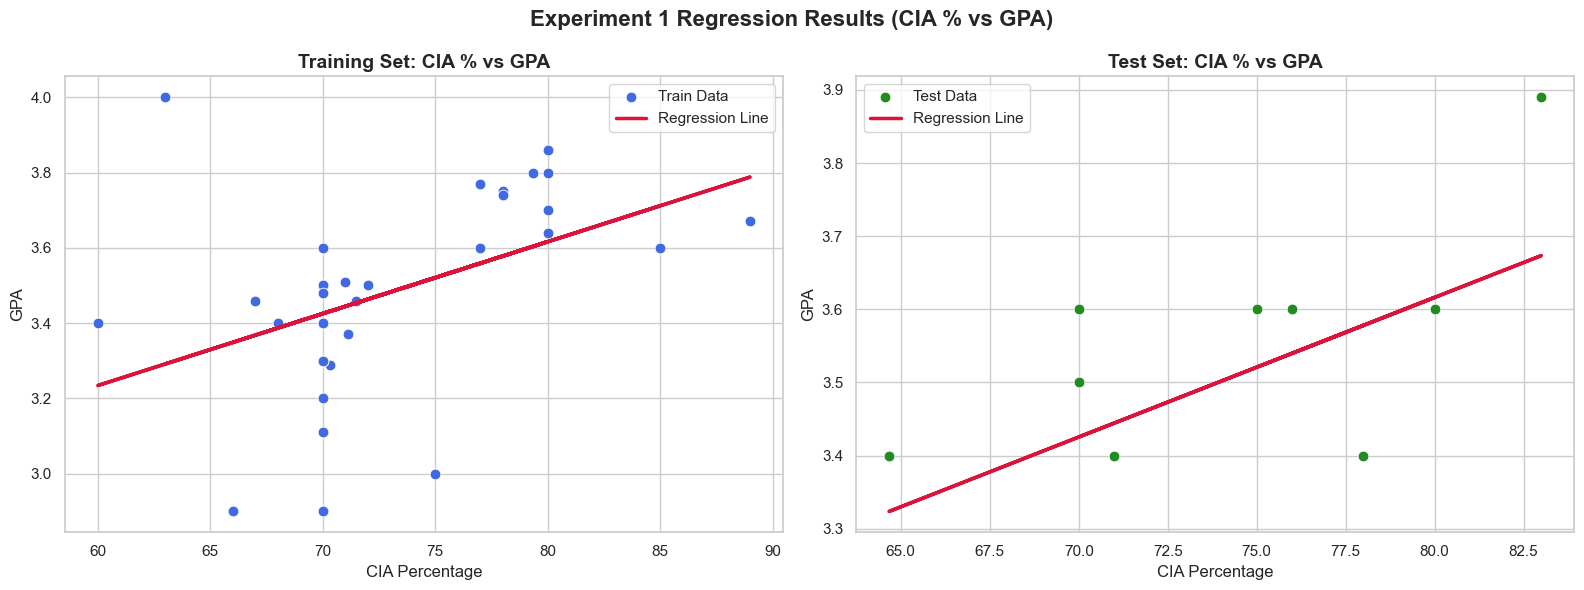

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(x=X_train_e1.ravel(), y=y_train_e1, ax=axes[0], color='royalblue', s=60, label='Train Data')
axes[0].plot(X_train_e1, model_sk_e1.predict(X_train_e1), color='crimson', linewidth=2.5, label='Regression Line')
axes[0].set_title('Training Set: CIA % vs GPA', fontsize=14, fontweight='bold')
axes[0].set_xlabel('CIA Percentage', fontsize=12)
axes[0].set_ylabel('GPA', fontsize=12)
axes[0].legend(fontsize=11)

sns.scatterplot(x=X_test_e1.ravel(), y=y_test_e1, ax=axes[1], color='forestgreen', s=60, label='Test Data')
axes[1].plot(X_test_e1, preds_sk_e1, color='crimson', linewidth=2.5, label='Regression Line')
axes[1].set_title('Test Set: CIA % vs GPA', fontsize=14, fontweight='bold')
axes[1].set_xlabel('CIA Percentage', fontsize=12)
axes[1].set_ylabel('GPA', fontsize=12)
axes[1].legend(fontsize=11)

plt.suptitle('Experiment 1 Regression Results (CIA % vs GPA)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

- **What it means**: There is a clear, positive pattern showing that **students with higher internal assessment (CIA) scores tend to have higher final GPAs**. For every **10% increase** in internal exam score, a student's GPA is expected to rise by about **0.19 points** (out of 4.0).

## **Experiment 2: Attendance Percentage (X) vs GPA (Y)**
1. Split the dataset into training (80%) and testing (20%) sets.
2. Fit a Scikit-learn `LinearRegression` model.
3. Manually compute parameters using OLS on the training set.
4. Compare predictions on the test set and plot the regression line.

In [7]:
X_exp2 = df_clean[['attendance_percentage']].values
y_exp2 = df_clean['gpa'].values

X_train_e2, X_test_e2, y_train_e2, y_test_e2 = train_test_split(
    X_exp2, y_exp2, test_size=0.2, random_state=42
)
print(f"Training shape: {X_train_e2.shape}, Testing shape: {X_test_e2.shape}")

model_sk_e2 = LinearRegression()
model_sk_e2.fit(X_train_e2, y_train_e2)

slope_sk_e2 = model_sk_e2.coef_[0]
intercept_sk_e2 = model_sk_e2.intercept_

print("\nScikit-learn Trained Parameters")
print(f"Slope (m): {slope_sk_e2:.6f}")
print(f"Intercept (b): {intercept_sk_e2:.6f}")

x_train_2d = X_train_e2.ravel()
y_train_2d = y_train_e2

x_mean_e2 = np.mean(x_train_2d)
y_mean_e2 = np.mean(y_train_2d)

numerator_e2 = np.sum((x_train_2d - x_mean_e2) * (y_train_2d - y_mean_e2))
denominator_e2 = np.sum((x_train_2d - x_mean_e2) ** 2)

slope_man_e2 = numerator_e2 / denominator_e2
intercept_man_e2 = y_mean_e2 - (slope_man_e2 * x_mean_e2)

print("\nManually Computed OLS Parameters")
print(f"Slope (m): {slope_man_e2:.6f}")
print(f"Intercept (b): {intercept_man_e2:.6f}")

preds_sk_e2 = model_sk_e2.predict(X_test_e2)
preds_man_e2 = slope_man_e2 * X_test_e2.ravel() + intercept_man_e2

diff_e2 = preds_sk_e2 - preds_man_e2

comparison_df_e2 = pd.DataFrame({
    'Actual GPA': y_test_e2,
    'Scikit-learn Prediction': preds_sk_e2,
    'Manual OLS Prediction': preds_man_e2,
    'Difference': diff_e2
})

print("\nPrediction Comparison Table (Test Set):")
print(comparison_df_e2.to_string(index=False))

max_diff_e2 = np.max(np.abs(diff_e2))
print(f"\nMaximum Absolute Difference: {max_diff_e2:.2e}")

Training shape: (33, 1), Testing shape: (9, 1)

Scikit-learn Trained Parameters
Slope (m): 0.021880
Intercept (b): 1.435272

Manually Computed OLS Parameters
Slope (m): 0.021880
Intercept (b): 1.435272

Prediction Comparison Table (Test Set):
 Actual GPA  Scikit-learn Prediction  Manual OLS Prediction    Difference
       3.60                 3.491987               3.491987  0.000000e+00
       3.60                 3.470107               3.470107  0.000000e+00
       3.40                 3.513867               3.513867 -4.440892e-16
       3.40                 3.404467               3.404467 -4.440892e-16
       3.89                 3.579507               3.579507 -4.440892e-16
       3.60                 3.595042               3.595042  0.000000e+00
       3.40                 3.623267               3.623267  0.000000e+00
       3.50                 3.338827               3.338827  0.000000e+00
       3.60                 3.448227               3.448227 -4.440892e-16

Maximum Absolute

### **Regression Visualizations (Experiment 2)**

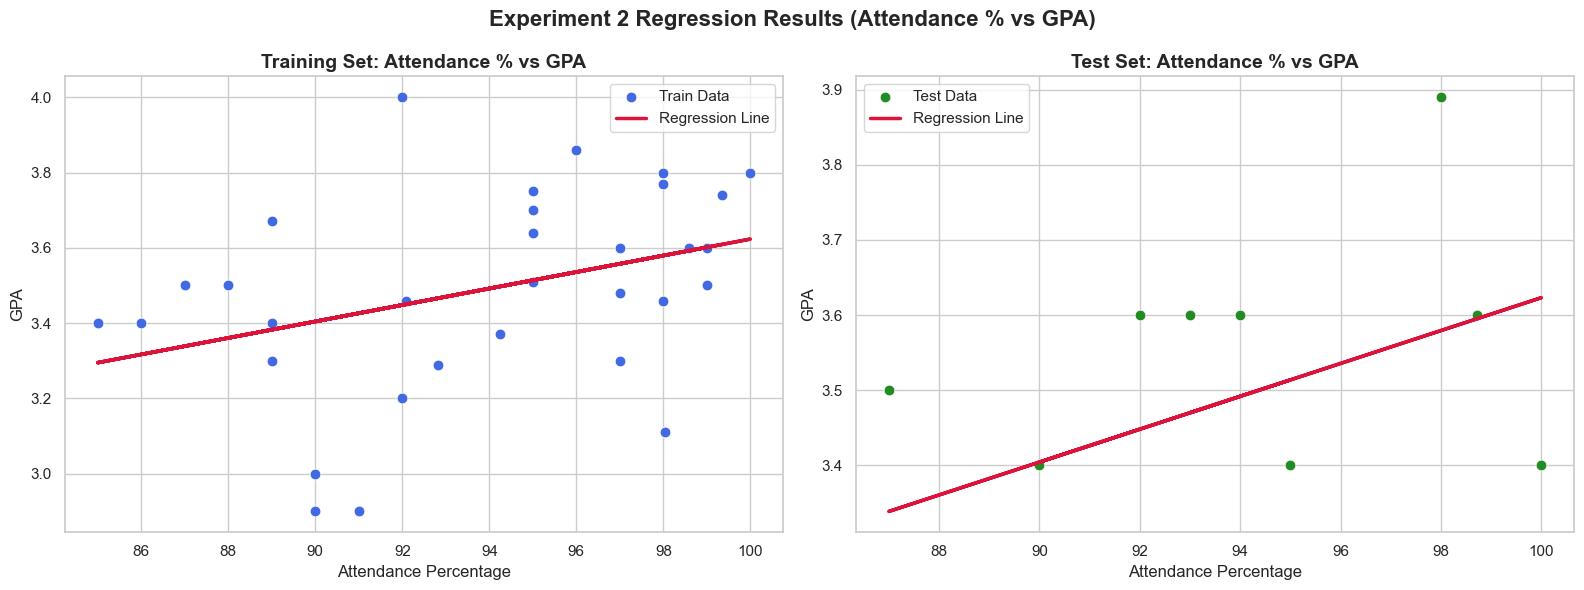

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(x=X_train_e2.ravel(), y=y_train_e2, ax=axes[0], color='royalblue', s=60, label='Train Data')
axes[0].plot(X_train_e2, model_sk_e2.predict(X_train_e2), color='crimson', linewidth=2.5, label='Regression Line')
axes[0].set_title('Training Set: Attendance % vs GPA', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Attendance Percentage', fontsize=12)
axes[0].set_ylabel('GPA', fontsize=12)
axes[0].legend(fontsize=11)

sns.scatterplot(x=X_test_e2.ravel(), y=y_test_e2, ax=axes[1], color='forestgreen', s=60, label='Test Data')
axes[1].plot(X_test_e2, preds_sk_e2, color='crimson', linewidth=2.5, label='Regression Line')
axes[1].set_title('Test Set: Attendance % vs GPA', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Attendance Percentage', fontsize=12)
axes[1].set_ylabel('GPA', fontsize=12)
axes[1].legend(fontsize=11)

plt.suptitle('Experiment 2 Regression Results (Attendance % vs GPA)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

- **What it means**: Class attendance has a clear, positive association with grades. **Students who attend class more regularly consistently achieve higher GPAs**. For every **10% increase** in attendance, a student's GPA is expected to increase by about **0.22 points** (out of 4.0).

## **Comparison & Observations**

1. **Mathematical Equivalence**: The slopes and intercepts computed using Scikit-learn's `LinearRegression` are identical to the values obtained using the manual OLS formulas.
2. **Experiment 1 (CIA % vs GPA)**:
   - The slope $m \approx 0.019$ indicates a positive relationship between CIA scores and final GPAs. For every $10\%$ increase in CIA, we expect a GPA increase of approximately $0.19$ points.
3. **Experiment 2 (Attendance % vs GPA)**:
   - The slope $m \approx 0.022$ suggests a positive relationship. For every $10\%$ increase in attendance, we expect a GPA increase of approximately $0.22$ points.

- **Attendance vs. Internal Exam Scores**: When we compare the two factors, **regularly attending class actually has a slightly larger positive impact on grades** than exam scores. A 10% increase in attendance corresponds to a **0.22 point GPA boost**, while a 10% increase in CIA scores corresponds to a **0.19 point GPA boost**.

## **Parameter Saving Task**

In [9]:
weights_to_save = {
    'experiment_1': {
        'feature_name': 'CIA Percentage',
        'slope': float(slope_sk_e1),
        'intercept': float(intercept_sk_e1)
    },
    'experiment_2': {
        'feature_name': 'Attendance Percentage',
        'slope': float(slope_sk_e2),
        'intercept': float(intercept_sk_e2)
    }
}

weights_filename = 'linear_regression_weights.pkl'

with open(weights_filename, 'wb') as f:
    pickle.dump(weights_to_save, f)

print(f"Successfully saved learned weights to '{weights_filename}' using Pickle.")

Successfully saved learned weights to 'linear_regression_weights.pkl' using Pickle.


### **Loading Parameters and Making Predictions**

In [10]:
with open(weights_filename, 'rb') as f:
    loaded_weights = pickle.load(f)

print("Loaded Weights Structure:")
print(loaded_weights)

def predict_gpa_using_weights(x_val, experiment_key):
    params = loaded_weights[experiment_key]
    m = params['slope']
    b = params['intercept']
    feature = params['feature_name']
    
    pred_gpa = m * x_val + b
    pred_gpa_clipped = max(0.0, min(4.0, pred_gpa))
    
    print(f"Experiment: {feature} -> GPA")
    print(f"Formula: GPA = {m:.5f} * X + {b:.5f}")
    print(f"Input {feature}: {x_val}%")
    print(f"Predicted GPA (Clipped): {pred_gpa_clipped:.4f}")
    if pred_gpa != pred_gpa_clipped:
        print(f"  (Raw predicted GPA was {pred_gpa:.4f})")
    print()

print("GPA Prediction Demonstrations")
predict_gpa_using_weights(75.0, 'experiment_1')
predict_gpa_using_weights(95.0, 'experiment_2')
predict_gpa_using_weights(50.0, 'experiment_1')
predict_gpa_using_weights(100.0, 'experiment_2')

Loaded Weights Structure:
{'experiment_1': {'feature_name': 'CIA Percentage', 'slope': 0.019091285054412023, 'intercept': 2.088885510753385}, 'experiment_2': {'feature_name': 'Attendance Percentage', 'slope': 0.021879948852717795, 'intercept': 1.4352718878120556}}
GPA Prediction Demonstrations
Experiment: CIA Percentage -> GPA
Formula: GPA = 0.01909 * X + 2.08889
Input CIA Percentage: 75.0%
Predicted GPA (Clipped): 3.5207

Experiment: Attendance Percentage -> GPA
Formula: GPA = 0.02188 * X + 1.43527
Input Attendance Percentage: 95.0%
Predicted GPA (Clipped): 3.5139

Experiment: CIA Percentage -> GPA
Formula: GPA = 0.01909 * X + 2.08889
Input CIA Percentage: 50.0%
Predicted GPA (Clipped): 3.0434

Experiment: Attendance Percentage -> GPA
Formula: GPA = 0.02188 * X + 1.43527
Input Attendance Percentage: 100.0%
Predicted GPA (Clipped): 3.6233



- **Scenario A (Average CIA student)**: A student who secures a **75% in internal exams (CIA)** is predicted to achieve a GPA of **3.52**.
- **Scenario B (Poor CIA student)**: A student who struggles and secures only **50% in internal exams** is predicted to achieve a much lower GPA of **3.04**.
- **Scenario C (Good attendance)**: A student who attends class regularly and gets **95% attendance** is predicted to achieve a GPA of **3.51**.
- **Scenario D (Perfect attendance)**: A student who never misses a class and gets **100% attendance** is predicted to achieve a higher GPA of **3.62**.